# Model 1 — AR(1) with Annual Cycle (PyMC)

In [1]:
import pymc as pm
import arviz as az
import pytensor.tensor as pt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.gofplots import qqplot
from statsmodels.tsa.stattools import acf
import os

sns.set_theme(style='whitegrid', font_scale=1.2)

/Users/fluffypony/Library/Mobile Documents/com~apple~CloudDocs/Documents/Galway/PROJECT/CODE/venv/lib/python3.14/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


In [2]:
output_folder = '../../data/models/model1_pymc/'
save_output   = False
if save_output:
    os.makedirs(output_folder, exist_ok=True)

## Preprocess

In [3]:
df = pd.read_csv('../../data/wide_weekly_scaledPer10k.csv')
regions  = df['Region'].tolist()
n_region = len(regions)
df = df.drop(columns='Region')
n_weeks = df.shape[1]

# Matrix: (n_region, n_weeks)
y_obs = df.values.astype(float)
print(f'Regions: {n_region}, Weeks: {n_weeks}')
print(regions)

Regions: 6, Weeks: 151
['HSE Dublin and Midlands', 'HSE Dublin and North East', 'HSE Dublin and South East', 'HSE Mid West', 'HSE South West', 'HSE West and North West']


## Model 1 Specification

AR(1) with annual sinusoidal cycle:

$$\mu_{i,t} = \alpha_i + \beta_i \cos\left(\frac{2\pi t}{52}\right) + \gamma_i \sin\left(\frac{2\pi t}{52}\right)$$

$$y_{i,1} \sim N(\mu_{i,1},\; \tau_i^{-1})$$

$$y_{i,t} \sim N\left(\mu_{i,t} + \phi(y_{i,t-1} - \mu_{i,t-1}),\; \tau_i^{-1}\right)$$

In [4]:
# Time index (1-indexed to match JAGS)
t_idx = np.arange(1, n_weeks + 1)
cos_t = np.cos(2 * np.pi * t_idx / 52)
sin_t = np.sin(2 * np.pi * t_idx / 52)

# JAGS precision 0.001 -> sigma = 1/sqrt(0.001) ~ 31.62
prior_sigma = 1.0 / np.sqrt(0.001)

with pm.Model() as model:
    # --- Priors ---
    alpha = pm.Normal('alpha', mu=0, sigma=prior_sigma, shape=n_region)
    beta  = pm.Normal('beta',  mu=0, sigma=prior_sigma, shape=n_region)
    gamma = pm.Normal('gamma', mu=0, sigma=prior_sigma, shape=n_region)
    tau   = pm.Gamma('tau', alpha=0.001, beta=0.001, shape=n_region)
    phi   = pm.Uniform('phi', lower=-1, upper=1)

    # --- Seasonal mean: mu[i,t] ---
    # shape: (n_region, n_weeks)
    mu = (alpha[:, None]
          + beta[:, None]  * cos_t[None, :]
          + gamma[:, None] * sin_t[None, :])

    # --- Full conditional mean ---
    # t=1: fullmod = mu[i,1]
    # t>1: fullmod = mu[i,t] + phi * (y[i,t-1] - mu[i,t-1])
    fullmod_first = mu[:, 0:1]
    fullmod_rest  = mu[:, 1:] + phi * (y_obs[:, :-1] - mu[:, :-1])
    fullmod = pt.concatenate([fullmod_first, fullmod_rest], axis=1)

    # --- Likelihood ---
    sigma_obs = 1.0 / pt.sqrt(tau)
    y = pm.Normal('y', mu=fullmod, sigma=sigma_obs[:, None],
                  observed=y_obs)

print(model.point_logps())

{'alpha': np.float64(-26.24), 'beta': np.float64(-26.24), 'gamma': np.float64(-26.24), 'tau': np.float64(-41.49), 'phi': np.float64(-1.39), 'y': np.float64(-13299.46)}


In [5]:
with model:
    trace = pm.sample(20000, tune=10000, chains=4,
                      return_inferencedata=True,
                      random_seed=42)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, gamma, tau, phi]


/Users/fluffypony/Library/Mobile 
Documents/com~apple~CloudDocs/Documents/Galway/PROJECT/CODE/venv/lib/python3.14/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 10_000 tune and 20_000 draw iterations (40_000 + 80_000 draws total) took 17 seconds.


## Summary

In [6]:
summary = az.summary(trace, var_names=['alpha','beta','gamma','tau','phi'],
                     hdi_prob=0.95)
summary

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha[0],3.821,0.184,3.459,4.181,0.000,0.001,181153.0,60268.0,1.0
alpha[1],2.176,0.120,1.940,2.411,0.000,0.000,164528.0,60128.0,1.0
alpha[2],2.868,0.136,2.603,3.138,0.000,0.001,169903.0,60706.0,1.0
alpha[3],7.966,0.299,7.372,8.546,0.001,0.001,180010.0,59755.0,1.0
alpha[4],4.269,0.223,3.822,4.704,0.001,0.001,180631.0,57981.0,1.0
alpha[5],6.185,0.261,5.673,6.699,0.001,0.001,186355.0,61158.0,1.0
beta[0],0.337,0.257,-0.179,0.829,0.001,0.001,172358.0,59669.0,1.0
beta[1],0.490,0.167,0.163,0.820,0.000,0.001,168041.0,59190.0,1.0
beta[2],0.461,0.191,0.086,0.836,0.000,0.001,167861.0,60849.0,1.0
beta[3],-0.523,0.413,-1.330,0.282,0.001,0.002,183104.0,62321.0,1.0


## Check Residuals

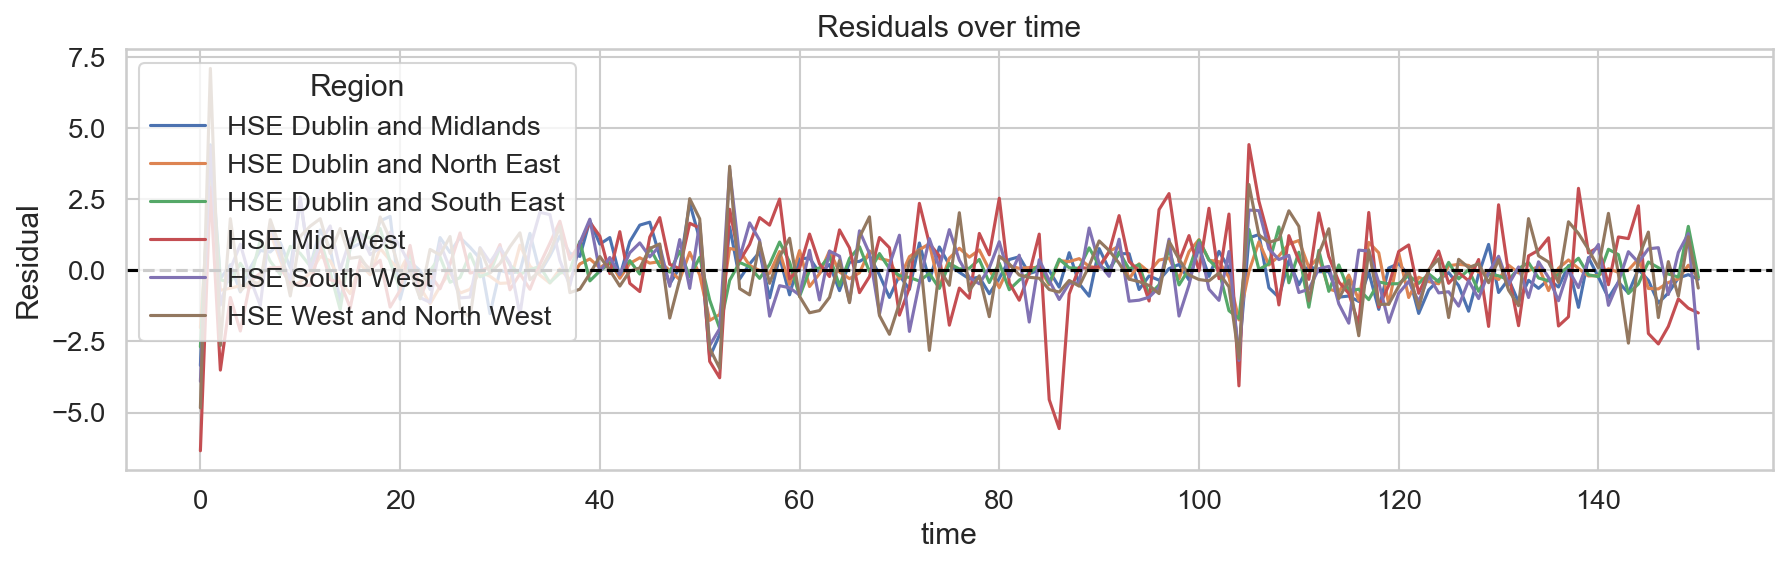

In [ ]:
# Extract posterior means for each parameter
alpha_mean = trace.posterior['alpha'].mean(dim=['chain','draw']).values
beta_mean  = trace.posterior['beta'].mean(dim=['chain','draw']).values
gamma_mean = trace.posterior['gamma'].mean(dim=['chain','draw']).values
tau_mean   = trace.posterior['tau'].mean(dim=['chain','draw']).values
phi_mean   = trace.posterior['phi'].mean(dim=['chain','draw']).values.item()

# Compute mu (n_region, n_weeks)
mu_hat = (alpha_mean[:, None]
          + beta_mean[:, None]  * cos_t[None, :]
          + gamma_mean[:, None] * sin_t[None, :])

# Compute fullmod
fullmod_hat = np.zeros_like(mu_hat)
fullmod_hat[:, 0] = mu_hat[:, 0]
for t in range(1, n_weeks):
    fullmod_hat[:, t] = mu_hat[:, t] + phi_mean * (y_obs[:, t-1] - mu_hat[:, t-1])

# Residuals
residuals = y_obs - fullmod_hat

# Plot
df_resid = pd.DataFrame(residuals.T, columns=regions)
df_resid['time'] = range(n_weeks)
df_long = df_resid.melt(id_vars='time', var_name='Region', value_name='Residual')

plt.figure(figsize=(12, 4), dpi=150)
sns.lineplot(data=df_long, x='time', y='Residual', hue='Region')
plt.axhline(y=0, color='black', linestyle='--')
plt.title('Residuals over time')
plt.tight_layout()

In [8]:
# Outliers
df_outliers = df_long[df_long['Residual'] < -3]
df_outliers

,time,Region,Residual
0,0,HSE Dublin and Midlands,-3.344004
51,51,HSE Dublin and Midlands,-3.048988
104,104,HSE Dublin and Midlands,-3.011474
453,0,HSE Mid West,-6.343168
455,2,HSE Mid West,-3.508140
504,51,HSE Mid West,-3.200985
505,52,HSE Mid West,-3.777724
538,85,HSE Mid West,-4.546191
539,86,HSE Mid West,-5.563959
557,104,HSE Mid West,-4.061966


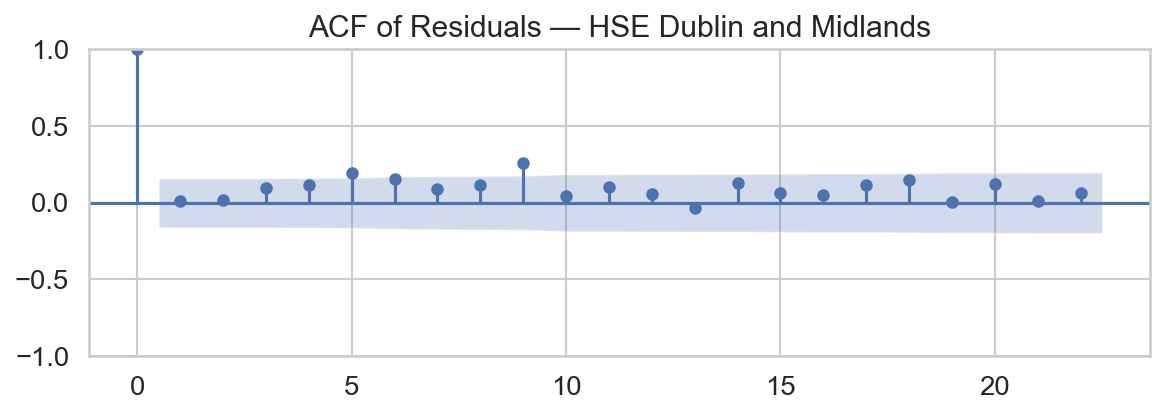

In [9]:
# ACF of residuals (first region)
fig, ax = plt.subplots(figsize=(8, 3), dpi=150)
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(residuals[0], ax=ax, title=f'ACF of Residuals — {regions[0]}')
plt.tight_layout()

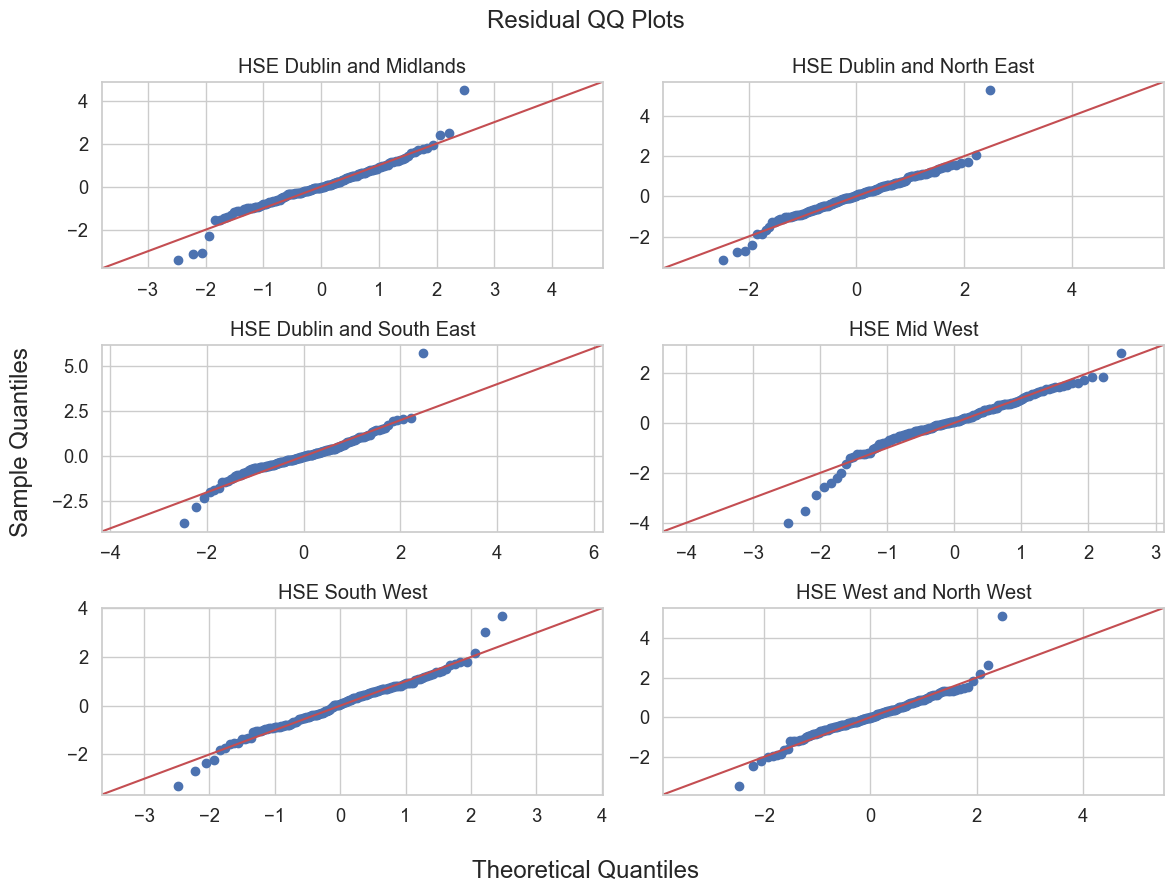

In [10]:
# QQ plot for each region
fig, axes = plt.subplots(3, 2, figsize=(12, 9))
for i, (ax, region) in enumerate(zip(axes.flatten(), regions)):
    std_resid = residuals[i] / residuals[i].std()
    qqplot(std_resid, line='45', ax=ax)
    ax.set_title(region)
    ax.set_xlabel('')
    ax.set_ylabel('')
fig.suptitle('Residual QQ Plots')
fig.supxlabel('Theoretical Quantiles')
fig.supylabel('Sample Quantiles')
plt.tight_layout()

## Check Convergence

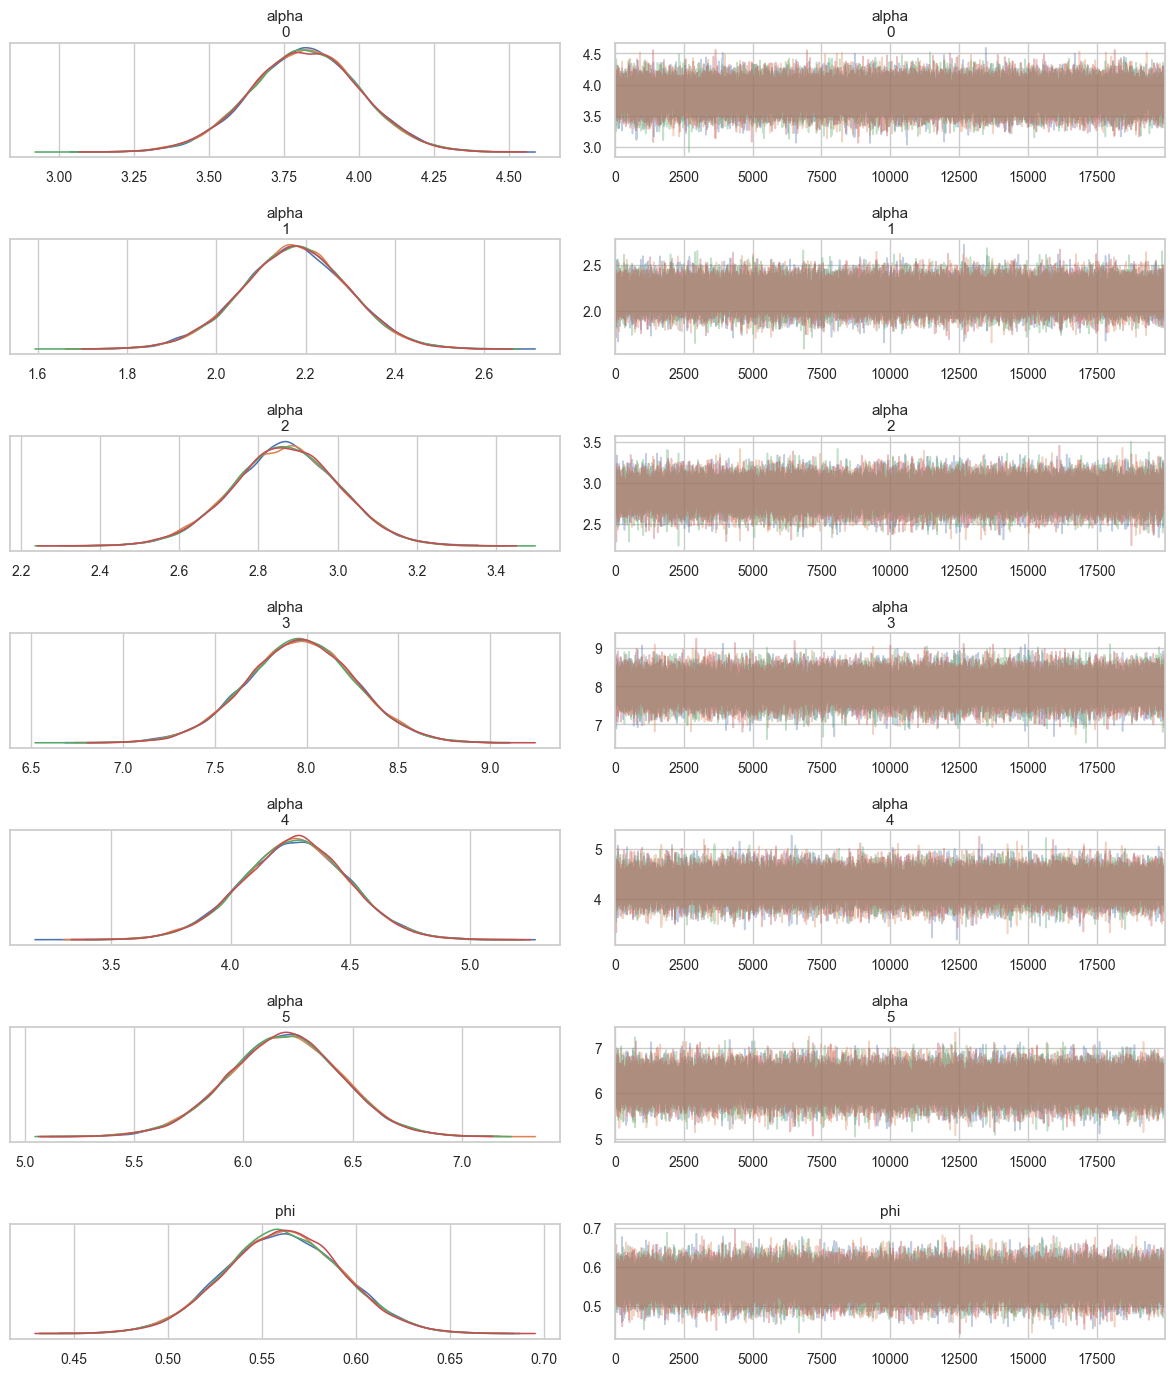

In [11]:
# Trace plots
az.plot_trace(trace, var_names=['alpha','phi'], compact=False)
plt.tight_layout()

### Gelman-Rubin (R-hat)

In [12]:
rhat = az.rhat(trace, var_names=['alpha','beta','gamma','tau','phi'])

# Flatten to a dataframe
rhat_rows = []
for var in rhat.data_vars:
    vals = rhat[var].values
    if vals.ndim == 0:
        rhat_rows.append({'parameter': var, 'rhat': float(vals)})
    else:
        for j, v in enumerate(vals):
            rhat_rows.append({'parameter': f'{var}[{j+1}]', 'rhat': float(v)})

df_rhat = pd.DataFrame(rhat_rows)
print(df_rhat.to_string(index=False))
print(f'\nMax R-hat: {df_rhat["rhat"].max():.4f}')

parameter     rhat
 alpha[1] 1.000034
 alpha[2] 1.000042
 alpha[3] 1.000100
 alpha[4] 1.000030
 alpha[5] 1.000068
 alpha[6] 1.000187
  beta[1] 1.000044
  beta[2] 1.000047
  beta[3] 1.000123
  beta[4] 1.000029
  beta[5] 1.000136
  beta[6] 1.000181
 gamma[1] 1.000089
 gamma[2] 1.000028
 gamma[3] 0.999990
 gamma[4] 1.000073
 gamma[5] 0.999987
 gamma[6] 0.999995
   tau[1] 1.000043
   tau[2] 1.000169
   tau[3] 1.000173
   tau[4] 0.999986
   tau[5] 1.000029
   tau[6] 1.000181
      phi 1.000071

Max R-hat: 1.0002


## Save

In [13]:
if save_output:
    # Raw samples
    post = trace.posterior.stack(sample=('chain','draw'))
    samples = {}
    for var in ['alpha','beta','gamma','tau','phi']:
        vals = post[var].values
        if vals.ndim == 1:
            samples[var] = vals
        else:
            for j in range(vals.shape[0]):
                samples[f'{var}[{j+1}]'] = vals[j]
    pd.DataFrame(samples).to_csv(
        os.path.join(output_folder, 'raw_samples.csv'),
        index=False)

    # Gelman
    df_rhat.to_csv(
        os.path.join(output_folder, 'gelman.csv'),
        index=False)

    print(f'Saved to {output_folder}')